First we will import the necessary libraries in the following block of code.

In [1]:
import numpy as np
from functools import reduce
from ripser import ripser
from collections import Counter
import matplotlib.pyplot as plt
from persim import plot_diagrams
import pandas as pd
from plottable import Table
import math


from math import floor, ceil


Currently this code works for cycle graphs only, next step (if we start examining different families of graphs) is converting the distance matrix calculation to be more robust.

In [47]:
cycleList = []
newVal = None
while newVal != 'q':
	newVal = input("Type a cycle size that you'd like to include in your product, or q to be done. ")
	if newVal != 'q':
		cycleList.append(int(newVal))
dimMin = int(input('What minimum dimension would you like to take the persistent homology in? '))   
dimMax = int(input('What maximum dimension would you like to take the persistent homology in? '))

In [48]:
#cycleList = [17, 5] # <--- Change cycles to (x)

def cycleDist(i,j,n): return min((i-j)%n,(j-i)%n) # Distance between points i and j in a cycle of size n
def cycleMatrix(n): return np.array([[cycleDist(i,j,n) for i in range(n)] for j in range(n)]) # Distance matrix for the cycle graph of size n

def product_sum(M, N): # computes the distance matrix of the product of two matrix spaces using the sum metric
	return np.block([[M + n for n in column] for column in N])

def maxProduct(M, N): # computes the distance matrix using the max matric rather than the sum metric
	return np.block([[np.maximum(M,n)  for n in column] for column in N])

def prism(M): return np.block([[M,M+1],[M+1,M]]) # Applies the prism operator we defined to a distance matrix (in other words, take the product of that metric space with the interval matric space using the sum metric

usePrism = False # <------------ CHANGE FOR PRISM OPERATION	
PrismCount = 0 # <------------ # of prism operations 

useMax = False # <------------ CHANGE FOR MAX/SUM 



It is currently unclear to me if the prism system here works but will revisit. 

In [49]:
if useMax:
    M = reduce(maxProduct, [cycleMatrix(n) for n in cycleList])
else:
    M = reduce(product_sum, [cycleMatrix(n) for n in cycleList])
if usePrism:
    for i in range(PrismCount):
        M = prism(M)

print("Distance matrix for the product graph:")
M

Distance matrix for the product graph:


array([[0, 1, 1, 1, 2, 2, 1, 2, 2],
       [1, 0, 1, 2, 1, 2, 2, 1, 2],
       [1, 1, 0, 2, 2, 1, 2, 2, 1],
       [1, 2, 2, 0, 1, 1, 1, 2, 2],
       [2, 1, 2, 1, 0, 1, 2, 1, 2],
       [2, 2, 1, 1, 1, 0, 2, 2, 1],
       [1, 2, 2, 1, 2, 2, 0, 1, 1],
       [2, 1, 2, 2, 1, 2, 1, 0, 1],
       [2, 2, 1, 2, 2, 1, 1, 1, 0]])

In [50]:
def PHCycle(n, k): # Gives the k-dimensional persistent homology of C_n
	if k == 0:
		return Counter({(0, 1) : n - 1, (0, float('inf')): 1})
	if k % 2 == 0:
		if n % (k + 1) == 0 and n != k + 1:
			return Counter({(int(k * n / (2 * (k + 1))), int(k * n / (2 * (k + 1)) + 1)) : int(n / (k + 1) - 1)})
		else:
			return Counter() 
	else:
		return Counter({(floor((k-1) / 2 * n / k) + 1, ceil((k + 1) / 2 * n / (k + 2))): 1})
def PHCycleAll(n):
	return lambda k : PHCycle(n, k)
def tensorOperation(i1, i2): # returns the tensor interval operation on two intervals
	return (i1[0] + i2[0], min(i1[0] + i2[1], i1[1] + i2[0]))
def torOperation(i1, i2):
	return (max(i1[0] + i2[1], i1[1] + i2[0]), i1[1] + i2[1])
def product(ph1, ph2, k): #ph1 and ph2 should be functions that take in K and give a Counter for PHk 
	# Calculate the tensor term
	ans = Counter()
	for i in range(k + 1): # this is the value of i that should add to j and give n
		j = k - i
		for key1, value1 in ph1(i).items():
			for key2, value2 in ph2(j).items():
				ans[tensorOperation(key1, key2)] += value1*value2	
	#tor term
	for i in range(k): # this is the value of i that should add to j and give n-1
		j = k - i - 1
		for key1, value1 in ph1(i).items():
			for key2, value2 in ph2(j).items():
				ans[torOperation(key1, key2)] += value1*value2	
	return ans
def productAll(ph1, ph2):
	return lambda k : product(ph1, ph2, k)
def stripEphemerals(counter):
	return {k: v for k, v in counter.items() if k[0] != k[1]}	
def predictedPersistentOfProduct(cycleSizeList, homologyDim):
	PHCycleFuncs = map(PHCycleAll, cycleSizeList)
	productFunc = reduce(productAll, PHCycleFuncs)
	return productFunc(homologyDim)

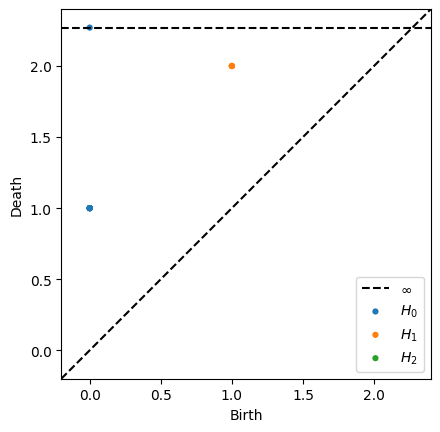

In [51]:
result = ripser(M, distance_matrix=True, maxdim = dimMax)
diagrams = result['dgms']

plot_diagrams(diagrams, show=True) # SCATTER PLOT

In [52]:

print("Persistence diagrams (with multiplicity):")
for i, diagram in enumerate(diagrams):
    print(f"H{i} diagram:")
    
    # Convert rows to tuples so they can be counted
    pairs = []
    for point in diagram:
        birth = int(round(point[0])) if np.isfinite(point[0]) else point[0]
        death = int(round(point[1])) if np.isfinite(point[1]) else point[1]
        pairs.append((birth, death))

    counts = Counter(pairs)
    
    # Print each unique pair and its count
    for pair, multiplicity in counts.items():
        print(f"  Birth/Death: {pair} -> Multiplicity: {multiplicity}")


Persistence diagrams (with multiplicity):
H0 diagram:
  Birth/Death: (0, 1) -> Multiplicity: 8
  Birth/Death: (0, np.float64(inf)) -> Multiplicity: 1
H1 diagram:
  Birth/Death: (1, 2) -> Multiplicity: 4
H2 diagram:


In [8]:
for dim in range(dimMin, dimMax + 1):
    print("\nDimension "+str(dim)+":") 
    print("With ephemerals stripped, the persistent homology is: " + str(dict(sorted(stripEphemerals(predictedPersistentOfProduct(cycleList, dim)).items()))))
    print("Without ephemerals stripped, the persistent homology is: " + str(dict(sorted(dict(predictedPersistentOfProduct(cycleList, dim)).items()))))


Dimension 0:
With ephemerals stripped, the persistent homology is: {(0, 1): 48, (0, inf): 1}
Without ephemerals stripped, the persistent homology is: {(0, 1): 48, (0, inf): 1}

Dimension 1:
With ephemerals stripped, the persistent homology is: {(1, 2): 48, (1, 3): 2}
Without ephemerals stripped, the persistent homology is: {(1, 2): 48, (1, 3): 2, (inf, inf): 13}

Dimension 2:
With ephemerals stripped, the persistent homology is: {(2, 4): 1, (3, 4): 12}
Without ephemerals stripped, the persistent homology is: {(2, 4): 1, (3, 4): 12, (inf, inf): 2}

Dimension 3:
With ephemerals stripped, the persistent homology is: {(4, 6): 1}
Without ephemerals stripped, the persistent homology is: {(3, 3): 14, (4, 6): 1}


Below is the script for running our PH_2 conjecture formula.

In [9]:
import math

def compute(n, m):

    a = math.ceil(n/3)
    b = math.ceil(m/3)

    if n % 3 == 0:
        p = ((n/3) - 1)
        n_mod3 = 0
    elif n % 3 == 1:
        p = 0
        n_mod3 = 1
    else:
        p = 0
        n_mod3 = 0

    if m % 3 == 0:
        q = ((m/3) - 1)
        m_mod3 = 0
    elif m % 3 == 1:
        q = 0
        m_mod3 = 1
    else:
        q = 0
        m_mod3 = 0

    if a < b:
        print(
        f"PH_2(C_{n} x C_{m}) = "
        f"[2, {a}]: 1, "
        f"[{a}, {a+1}]: {m*n_mod3 + p*m}, "
        f"[{b}, {b+1}]: {(n-1)*m_mod3 + q*n}"
)
    else:
        print(
        f"PH_2(C_{n} x C_{m}) = "
        f"[2, {a}]: 1, "
        f"[{a}, {a+1}]: "
        f"{n_mod3*m_mod3 + (m-1)*n_mod3 + (n-1)*m_mod3 + p*m + q*n}"
)
n = input("Enter n: " )
m = input("Enter m: " )

n = int(n)
m = int(m)

if m < n:
    n, m = m, n

if (n % 3 ==1) or (m % 3 == 1):
    compute(n, m)

In [53]:

cyclemin = int(input('What minimum cycle size would you like to take the persistent homology in? '))  
cyclemax = int(input('What maximum cycle size would you like to take the persistent homology in? '))
dimMin = int(input('What minimum dimension would you like to take the persistent homology in? '))   
dimMax = int(input('What maximum dimension would you like to take the persistent homology in? '))

grid_size = cyclemax - cyclemin + 1
MGrid = [[0] * (grid_size) for _ in range(grid_size)]

grid_size = cyclemax - cyclemin + 1
MGrid_conjecture = [[0] * (grid_size) for _ in range(grid_size)]

for n in range(cyclemin, cyclemax+1):
    row_idx = n - cyclemin
    for m in range(n, cyclemax + 1):
        col_idx = m - cyclemin
        M = product_sum(cycleMatrix(n),cycleMatrix(m))
        result = ripser(M, distance_matrix=True, maxdim = dimMax)
        dgms_data = result['dgms']

        # AI Code ---------
        clean_cell_data = {}
        
        for dim in range(dimMin, dimMax + 1):
            if dim < len(dgms_data) and len(dgms_data[dim]) > 0:
                intervals = [
                    (int(round(b, 2)) if round(b, 2).is_integer() else round(b, 2),
                    int(round(d, 2)) if round(d, 2).is_integer() else round(d, 2)) 
                    for b, d in dgms_data[dim]]
                
                clean_cell_data[dim] = dict(Counter(intervals))
            else:
                clean_cell_data[dim] = {} 
        # ----------
        MGrid[row_idx][col_idx] = clean_cell_data
        MGrid[col_idx][row_idx] = clean_cell_data

        MGrid_conjecture[row_idx][col_idx] = compute(n, m)
        MGrid_conjecture[col_idx][row_idx] = compute(n, m)

        

#MGrid
            

PH_2(C_3 x C_3) = [2, 1]: 1, [1, 2]: 0.0
PH_2(C_3 x C_3) = [2, 1]: 1, [1, 2]: 0.0
PH_2(C_3 x C_4) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 2
PH_2(C_3 x C_4) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 2
PH_2(C_3 x C_5) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 0
PH_2(C_3 x C_5) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 0
PH_2(C_3 x C_6) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 3.0
PH_2(C_3 x C_6) = [2, 1]: 1, [1, 2]: 0.0, [2, 3]: 3.0
PH_2(C_3 x C_7) = [2, 1]: 1, [1, 2]: 0.0, [3, 4]: 2
PH_2(C_3 x C_7) = [2, 1]: 1, [1, 2]: 0.0, [3, 4]: 2
PH_2(C_4 x C_4) = [2, 2]: 1, [2, 3]: 7
PH_2(C_4 x C_4) = [2, 2]: 1, [2, 3]: 7
PH_2(C_4 x C_5) = [2, 2]: 1, [2, 3]: 4
PH_2(C_4 x C_5) = [2, 2]: 1, [2, 3]: 4
PH_2(C_4 x C_6) = [2, 2]: 1, [2, 3]: 9.0
PH_2(C_4 x C_6) = [2, 2]: 1, [2, 3]: 9.0
PH_2(C_4 x C_7) = [2, 2]: 1, [2, 3]: 7, [3, 4]: 3
PH_2(C_4 x C_7) = [2, 2]: 1, [2, 3]: 7, [3, 4]: 3
PH_2(C_5 x C_5) = [2, 2]: 1, [2, 3]: 0
PH_2(C_5 x C_5) = [2, 2]: 1, [2, 3]: 0
PH_2(C_5 x C_6) = [2, 2]: 1, [2, 3]: 5.0
PH_2(C_5 x C_6) = [2, 2]: 1, [2, 3]: 5.0


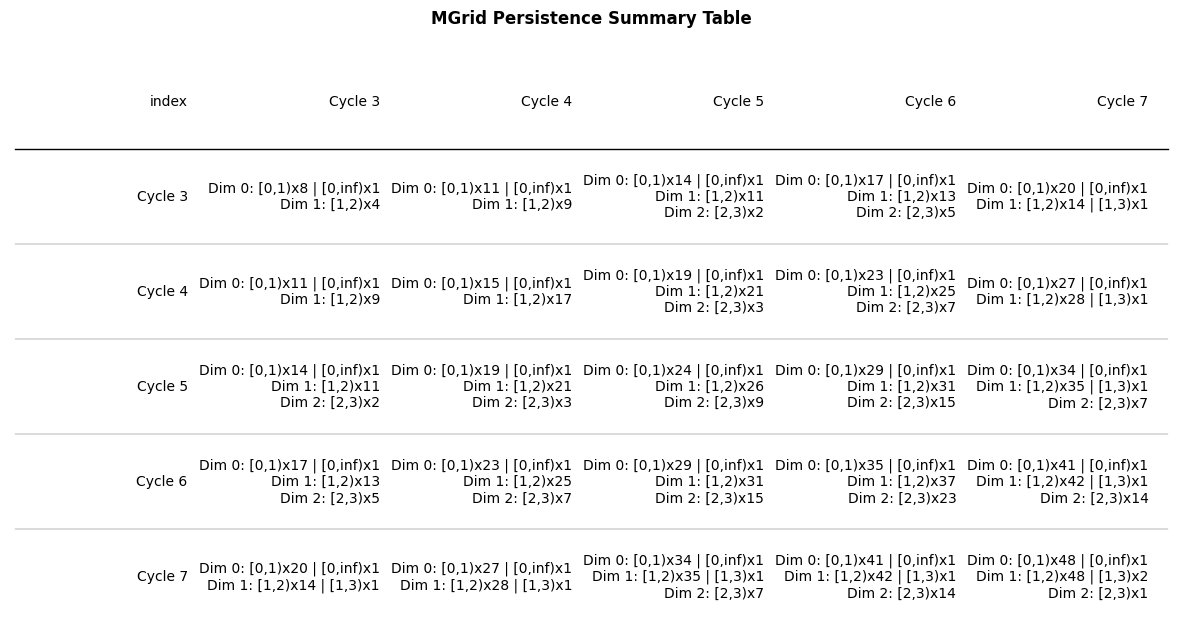

In [54]:
#AI Code for table here --------------------------------------------->
# 1. Setup labels
labels = [f"Cycle {i}" for i in range(cyclemin, cyclemax + 1)]

# 2. Convert MGrid dictionary into simple text lines
simple_grid = []
for row in MGrid:
    simple_row = []
    for cell_data in row:
        if cell_data == 0 or not any(cell_data.values()):
            simple_row.append("Empty")
            continue
            
        lines = []
        for dim, bars in cell_data.items():
            if bars:
                bar_strs = [f"[{b},{d})x{m}" for (b, d), m in bars.items()]
                lines.append(f"Dim {dim}: " + " | ".join(bar_strs))
        
        # Join dimensions with a clear line break
        simple_row.append("\n".join(lines))
    simple_grid.append(simple_row)

# 3. Put into a Pandas DataFrame
df = pd.DataFrame(simple_grid, index=labels, columns=labels)

# 4. Create the perfect auto-expanding table
# We make the figure wide enough to give columns breathing room
fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))

# Plottable automatically sizes everything based on the text length!
tab = Table(df, ax=ax)

plt.title("MGrid Persistence Summary Table", weight='bold', pad=20)
plt.show()


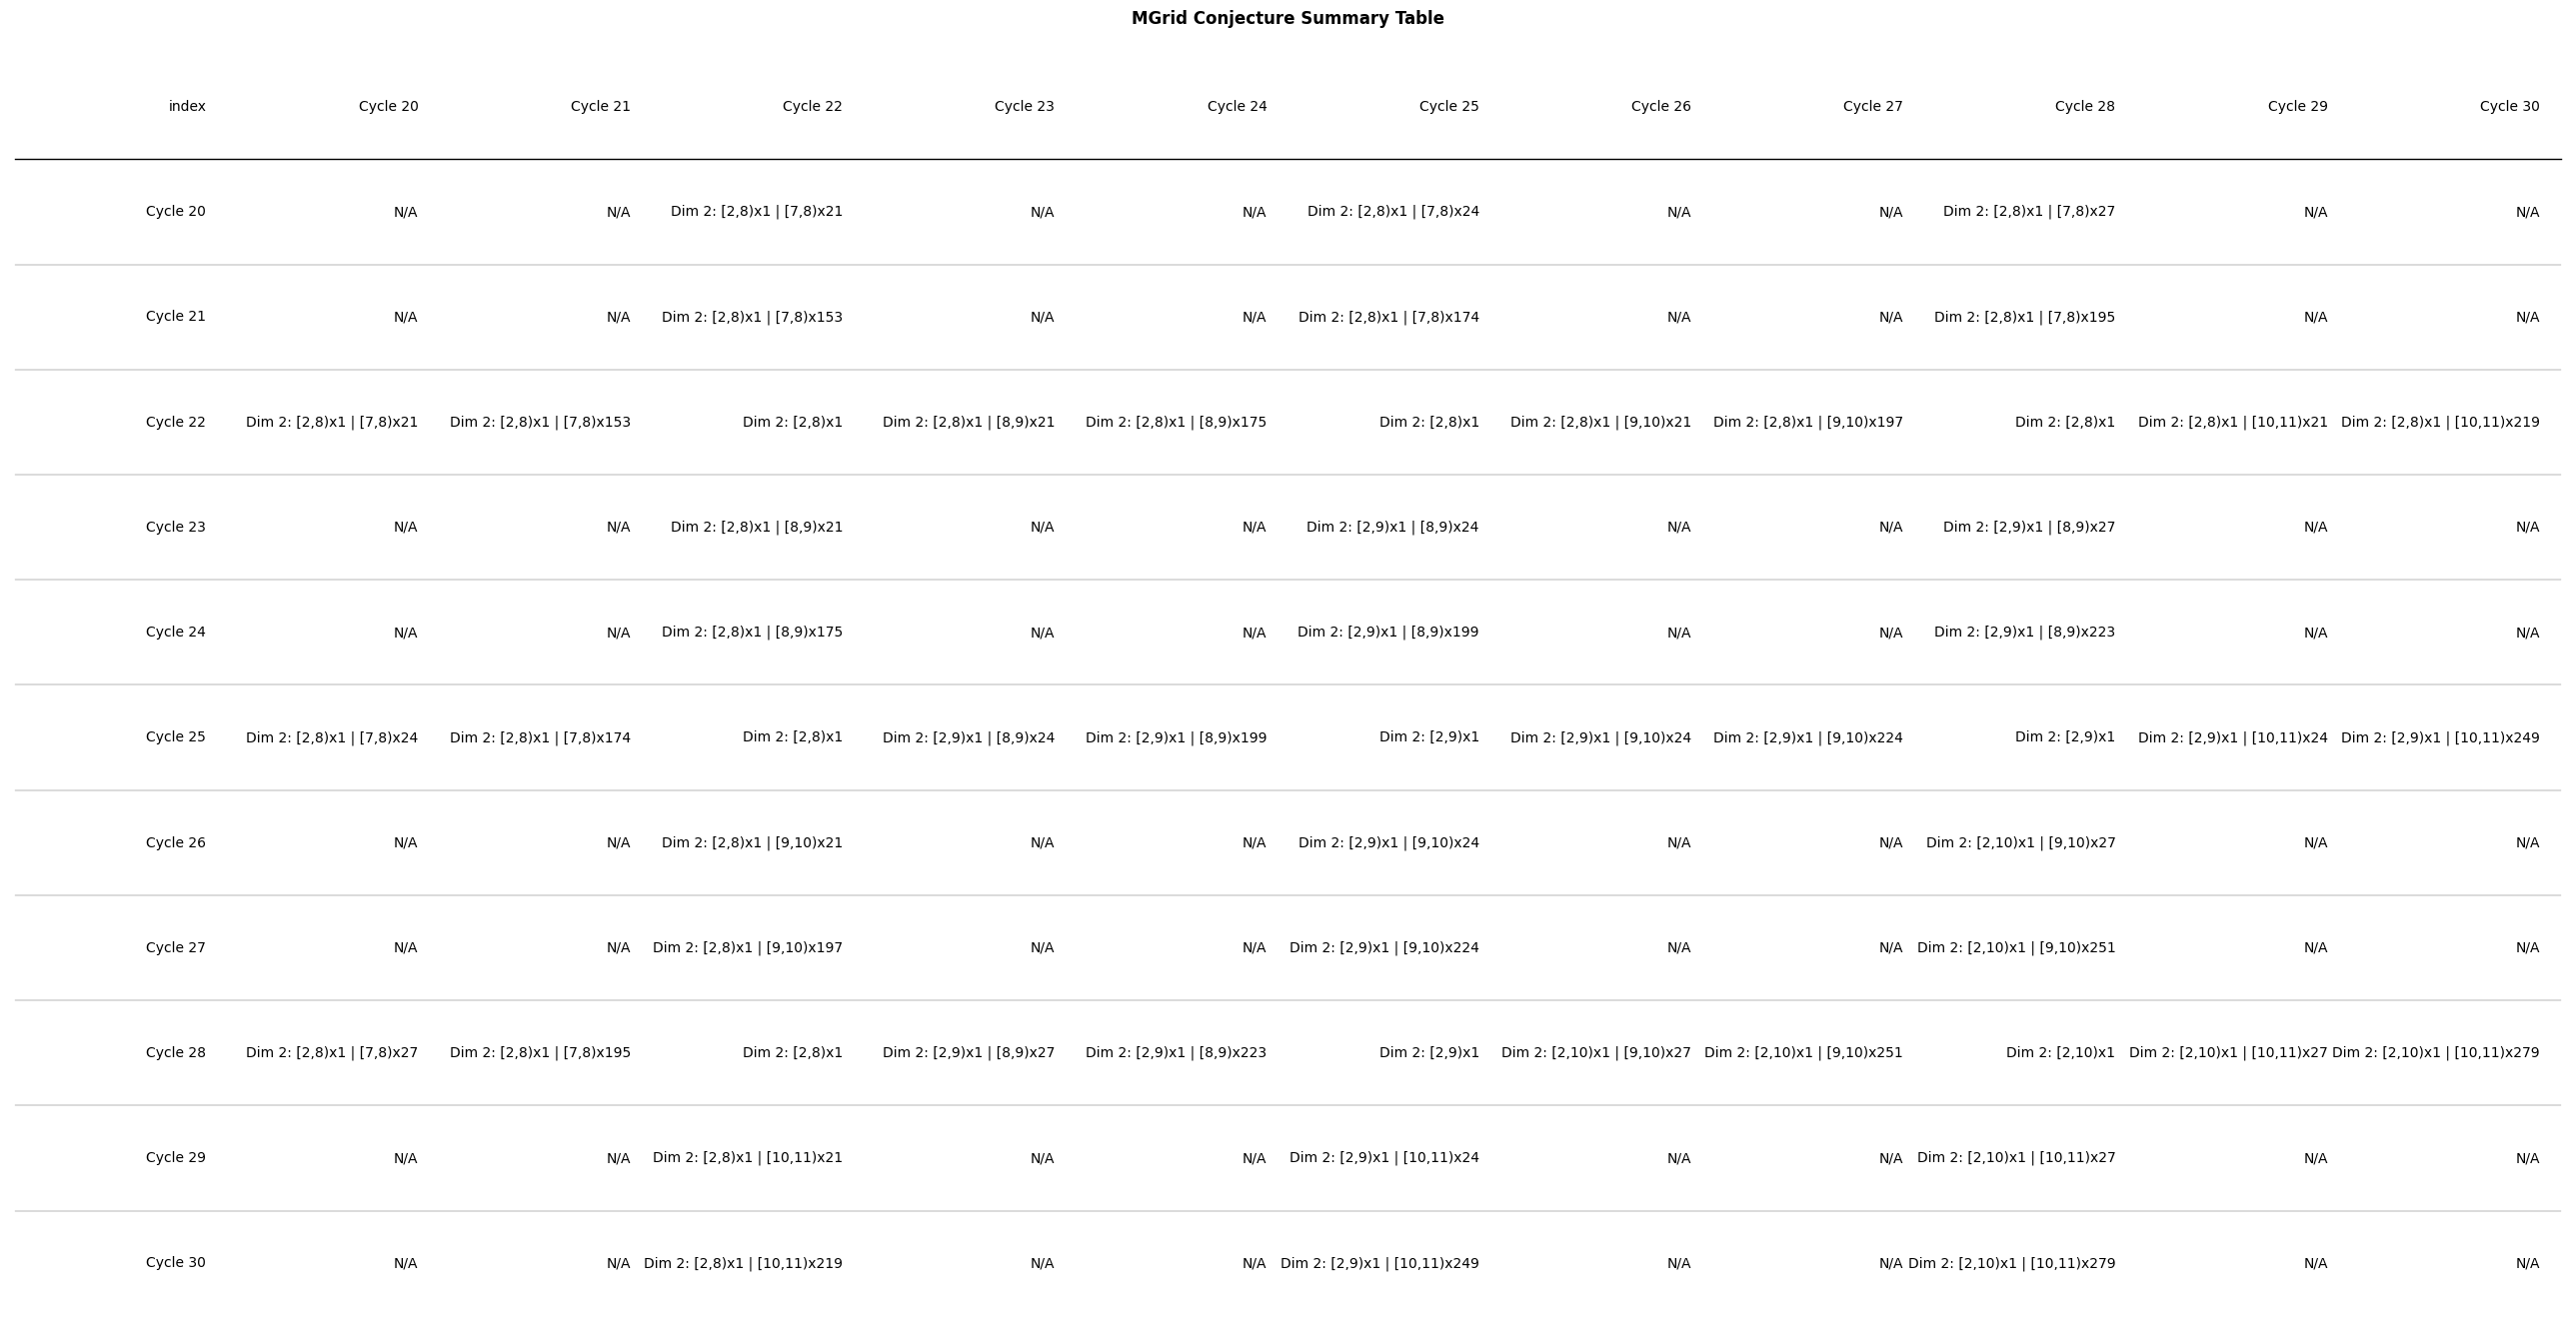

In [44]:
# AI Code for table here --------------------------------------------->

# 1. Setup labels
labels = [f"Cycle {i}" for i in range(cyclemin, cyclemax + 1)]

# 2. Inline version of compute() that returns a dict instead of printing
def compute_dict(n, m):
    if m < n:
        swap = m 
        m = n
        n = swap

    a = math.ceil(n/3)
    b = math.ceil(m/3)
    #print(n, m, a, b)

    if n % 3 == 0:
        p = (n/3) - 1;  n_mod3 = 1
    elif n % 3 == 1:
        p = 0;           n_mod3 = 0
    else:
        p = 0;           n_mod3 = 1

    if m % 3 == 0:
        q = (m/3) - 1;  m_mod3 = 1
    elif m % 3 == 1:
        q = 0;           m_mod3 = 0
    else:
        q = 0;           m_mod3 = 1


    if a < b:

        if a <= 2:
            bars = {(a, a+1): int(m*n_mod3 + p*m), (b, b+1): int((n-1)*m_mod3 + q*n)}
        else:
            if (n%3) != 1:
                bars = {(2, a+1): 1, (a, a+1): int(m*n_mod3 + p*m - 1), (b, b+1): int((n-1)*m_mod3 + q*n)}
            else:
                bars = {(2, a): 1, (a, a+1): int(m*n_mod3 + p*m), (b, b+1): int((n-1)*m_mod3 + q*n)}
    else:
        if a <= 2:
            bars = {(a, a+1): int(n_mod3*m_mod3 + (m-1)*n_mod3 + (n-1)*m_mod3 + p*m + q*n)}
        else:
            bars = {(2, a): 1, (a, a+1): int(n_mod3*m_mod3 + (m-1)*n_mod3 + (n-1)*m_mod3 + p*m + q*n)}

    return {2: {k: v for k, v in bars.items() if v > 0}}

# 3. Rebuild MGrid_conjecture as proper dicts
grid_size = cyclemax - cyclemin + 1
MGrid_conjecture_dict = [[None] * grid_size for _ in range(grid_size)]
for n in range(cyclemin, cyclemax + 1):
    for m in range(cyclemin, cyclemax + 1):
        ni, mi = n - cyclemin, m - cyclemin
        lo, hi = (n, m) if n <= m else (m, n)
        if (lo % 3 == 1) or (hi % 3 == 1):
            MGrid_conjecture_dict[ni][mi] = compute_dict(lo, hi)
        # else leave as None (conjecture doesn't apply)

# 4. Convert to simple text lines
simple_grid = []
for row in MGrid_conjecture_dict:
    simple_row = []
    for cell_data in row:
        if cell_data is None or not any(cell_data.values()):
            simple_row.append("N/A")
            continue

        lines = []
        for dim, bars in cell_data.items():
            if bars:
                bar_strs = [f"[{b},{d})x{m}" for (b, d), m in bars.items()]
                lines.append(f"Dim {dim}: " + " | ".join(bar_strs))

        simple_row.append("\n".join(lines))
    simple_grid.append(simple_row)

# 5. Put into a Pandas DataFrame and plot
df = pd.DataFrame(simple_grid, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))
tab = Table(df, ax=ax)
plt.title("MGrid Conjecture Summary Table", weight='bold', pad=20)
plt.show()

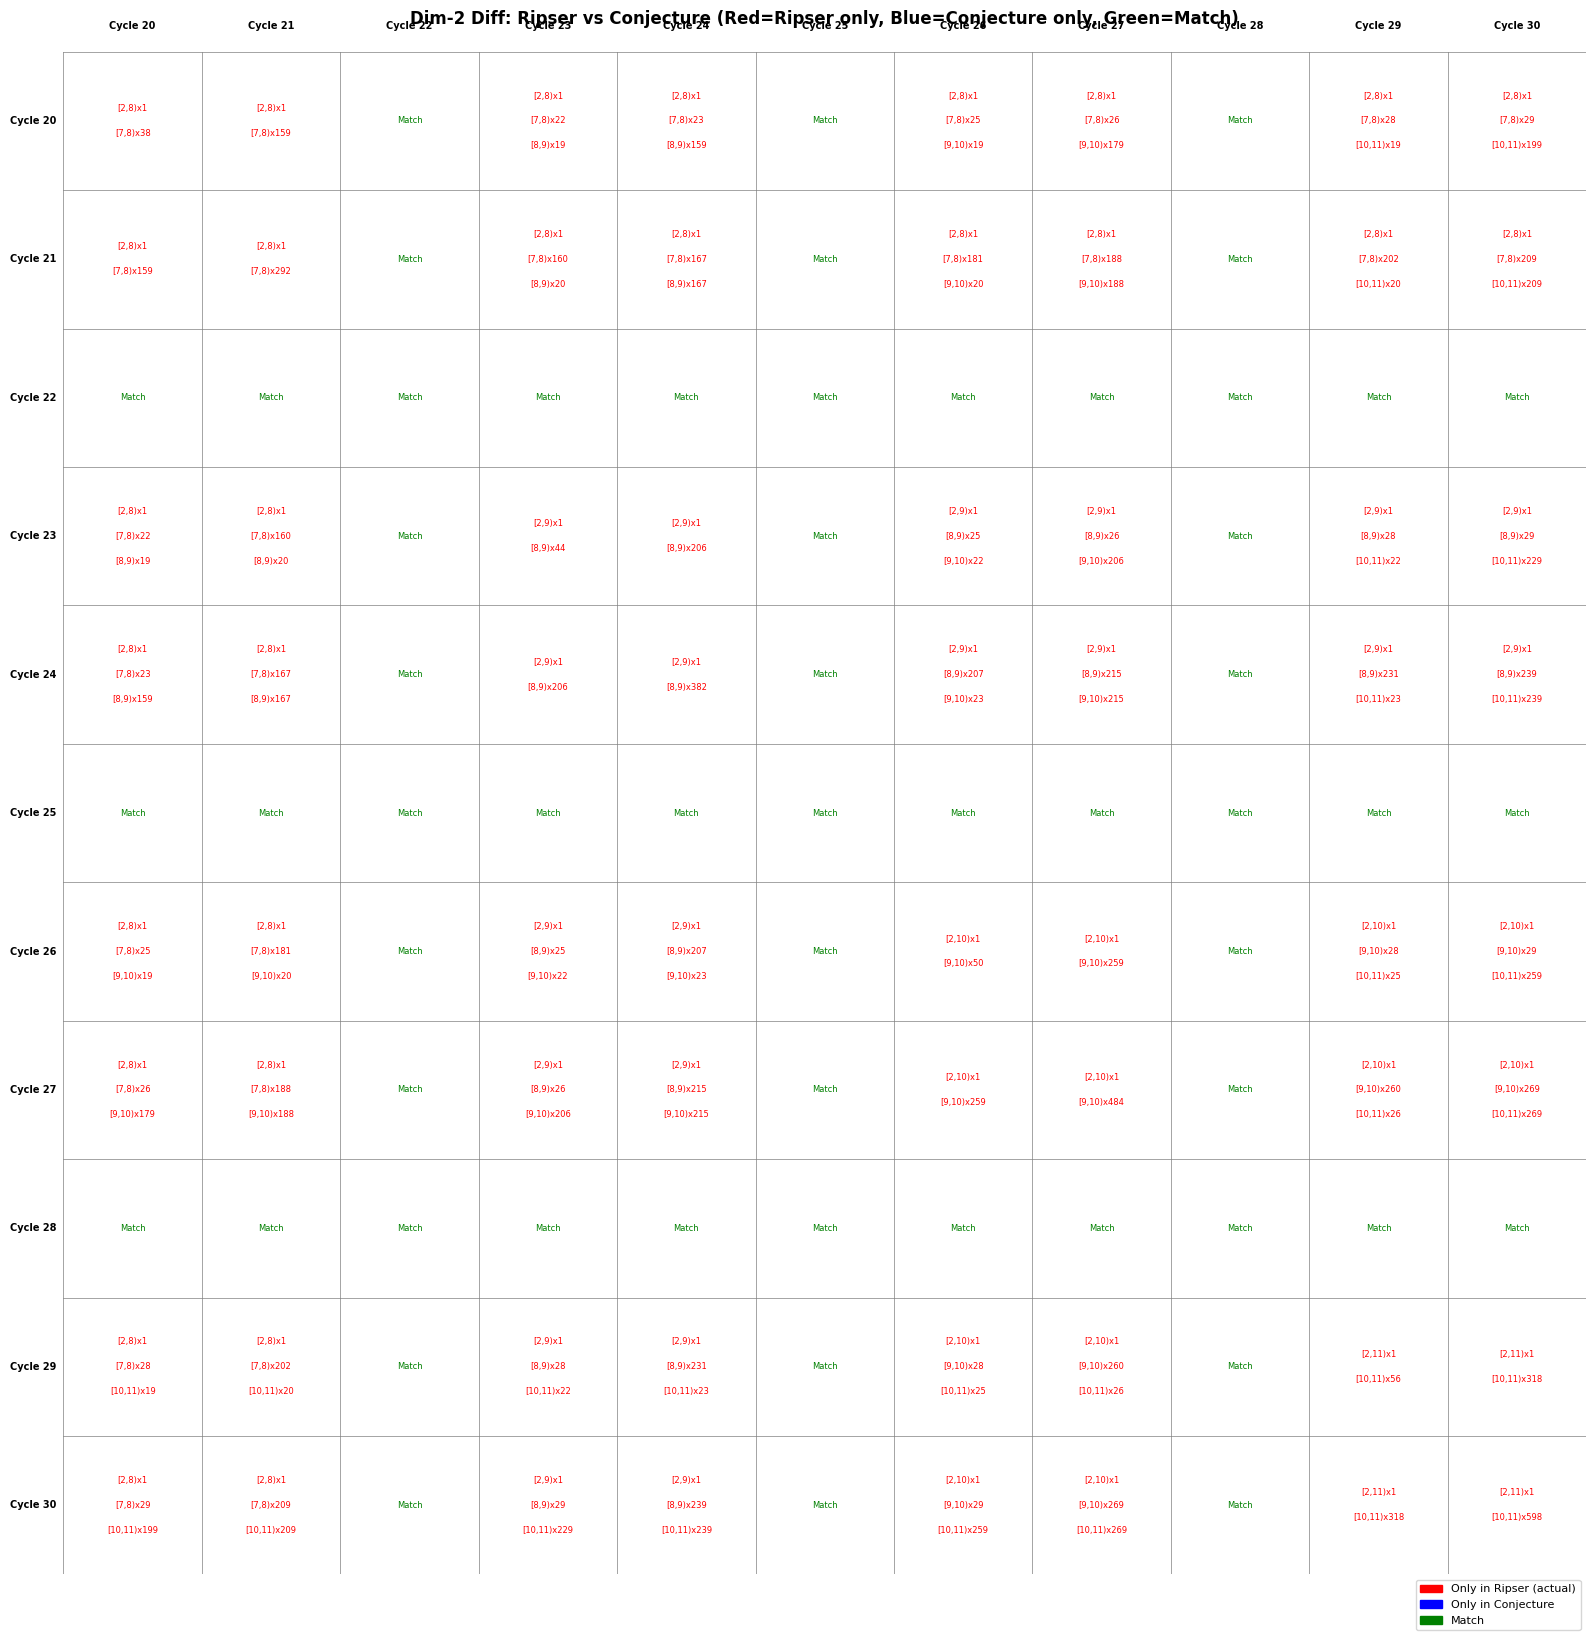

In [45]:
# AI Code for DIFF table --------------------------------------------->
import matplotlib.patches as mpatches

# 1. Labels already defined above

# 2. Build diff grid
diff_grid = []
for row_idx in range(grid_size):
    diff_row = []
    for col_idx in range(grid_size):
        ripser_cell = MGrid[row_idx][col_idx]
        conj_cell   = MGrid_conjecture_dict[row_idx][col_idx]

        # Extract dim-2 bars from Ripser
        ripser_bars = {}
        if ripser_cell and ripser_cell != 0:
            ripser_bars = ripser_cell.get(2, {})

        # Extract dim-2 bars from conjecture
        conj_bars = {}
        if conj_cell and conj_cell != 0:
            conj_bars = conj_cell.get(2, {})

        # Find bars unique to each side
        all_keys = set(ripser_bars.keys()) | set(conj_bars.keys())
        only_ripser = {}  # red
        only_conj   = {}  # blue

        for k in all_keys:
            r_mult = ripser_bars.get(k, 0)
            c_mult = conj_bars.get(k, 0)
            if r_mult != c_mult:
                # Show the differing multiplicity on each side if nonzero
                if r_mult > 0:
                    only_ripser[k] = r_mult
                if c_mult > 0:
                    only_conj[k] = c_mult

        diff_row.append((only_ripser, only_conj))
    diff_grid.append(diff_row)

# 3. Render table manually with colored text
fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_aspect('equal')
ax.axis('off')

col_w = 1.0  # width of each cell
row_h = 1.0  # height of each cell

# Draw grid lines
for i in range(grid_size + 1):
    ax.axhline(i, color='gray', linewidth=0.5)
    ax.axvline(i, color='gray', linewidth=0.5)

# Column headers (top)
for col_idx, label in enumerate(labels):
    ax.text((col_idx + 0.5) * col_w, grid_size + 0.15, label,
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# Row headers (left)
for row_idx, label in enumerate(labels):
    ax.text(-0.05, (grid_size - row_idx - 0.5) * row_h, label,
            ha='right', va='center', fontsize=7, fontweight='bold')

# Fill cells
for row_idx in range(grid_size):
    for col_idx in range(grid_size):
        only_ripser, only_conj = diff_grid[row_idx][col_idx]

        lines   = []  # list of (text, color)

        for (b, d), mult in sorted(only_ripser.items()):
            lines.append((f"[{b},{d})x{mult}", 'red'))
        for (b, d), mult in sorted(only_conj.items()):
            lines.append((f"[{b},{d})x{mult}", 'blue'))

        if not lines:
            lines = [("Match", 'green')]

        # Center the block of lines vertically in the cell
        n_lines = len(lines)
        cell_cx = (col_idx + 0.5) * col_w
        cell_cy = (grid_size - row_idx - 0.5) * row_h
        line_spacing = 0.18
        start_y = cell_cy + (n_lines - 1) * line_spacing / 2

        for li, (txt, color) in enumerate(lines):
            ax.text(cell_cx, start_y - li * line_spacing, txt,
                    ha='center', va='center', fontsize=6, color=color)

# Legend
red_patch  = mpatches.Patch(color='red',   label='Only in Ripser (actual)')
blue_patch = mpatches.Patch(color='blue',  label='Only in Conjecture')
grn_patch  = mpatches.Patch(color='green', label='Match')
ax.legend(handles=[red_patch, blue_patch, grn_patch],
          loc='upper right', bbox_to_anchor=(1.0, 0.0), fontsize=8)

plt.title("Dim-2 Diff: Ripser vs Conjecture (Red=Ripser only, Blue=Conjecture only, Green=Match)",
          weight='bold', pad=20)
plt.tight_layout()
plt.show()

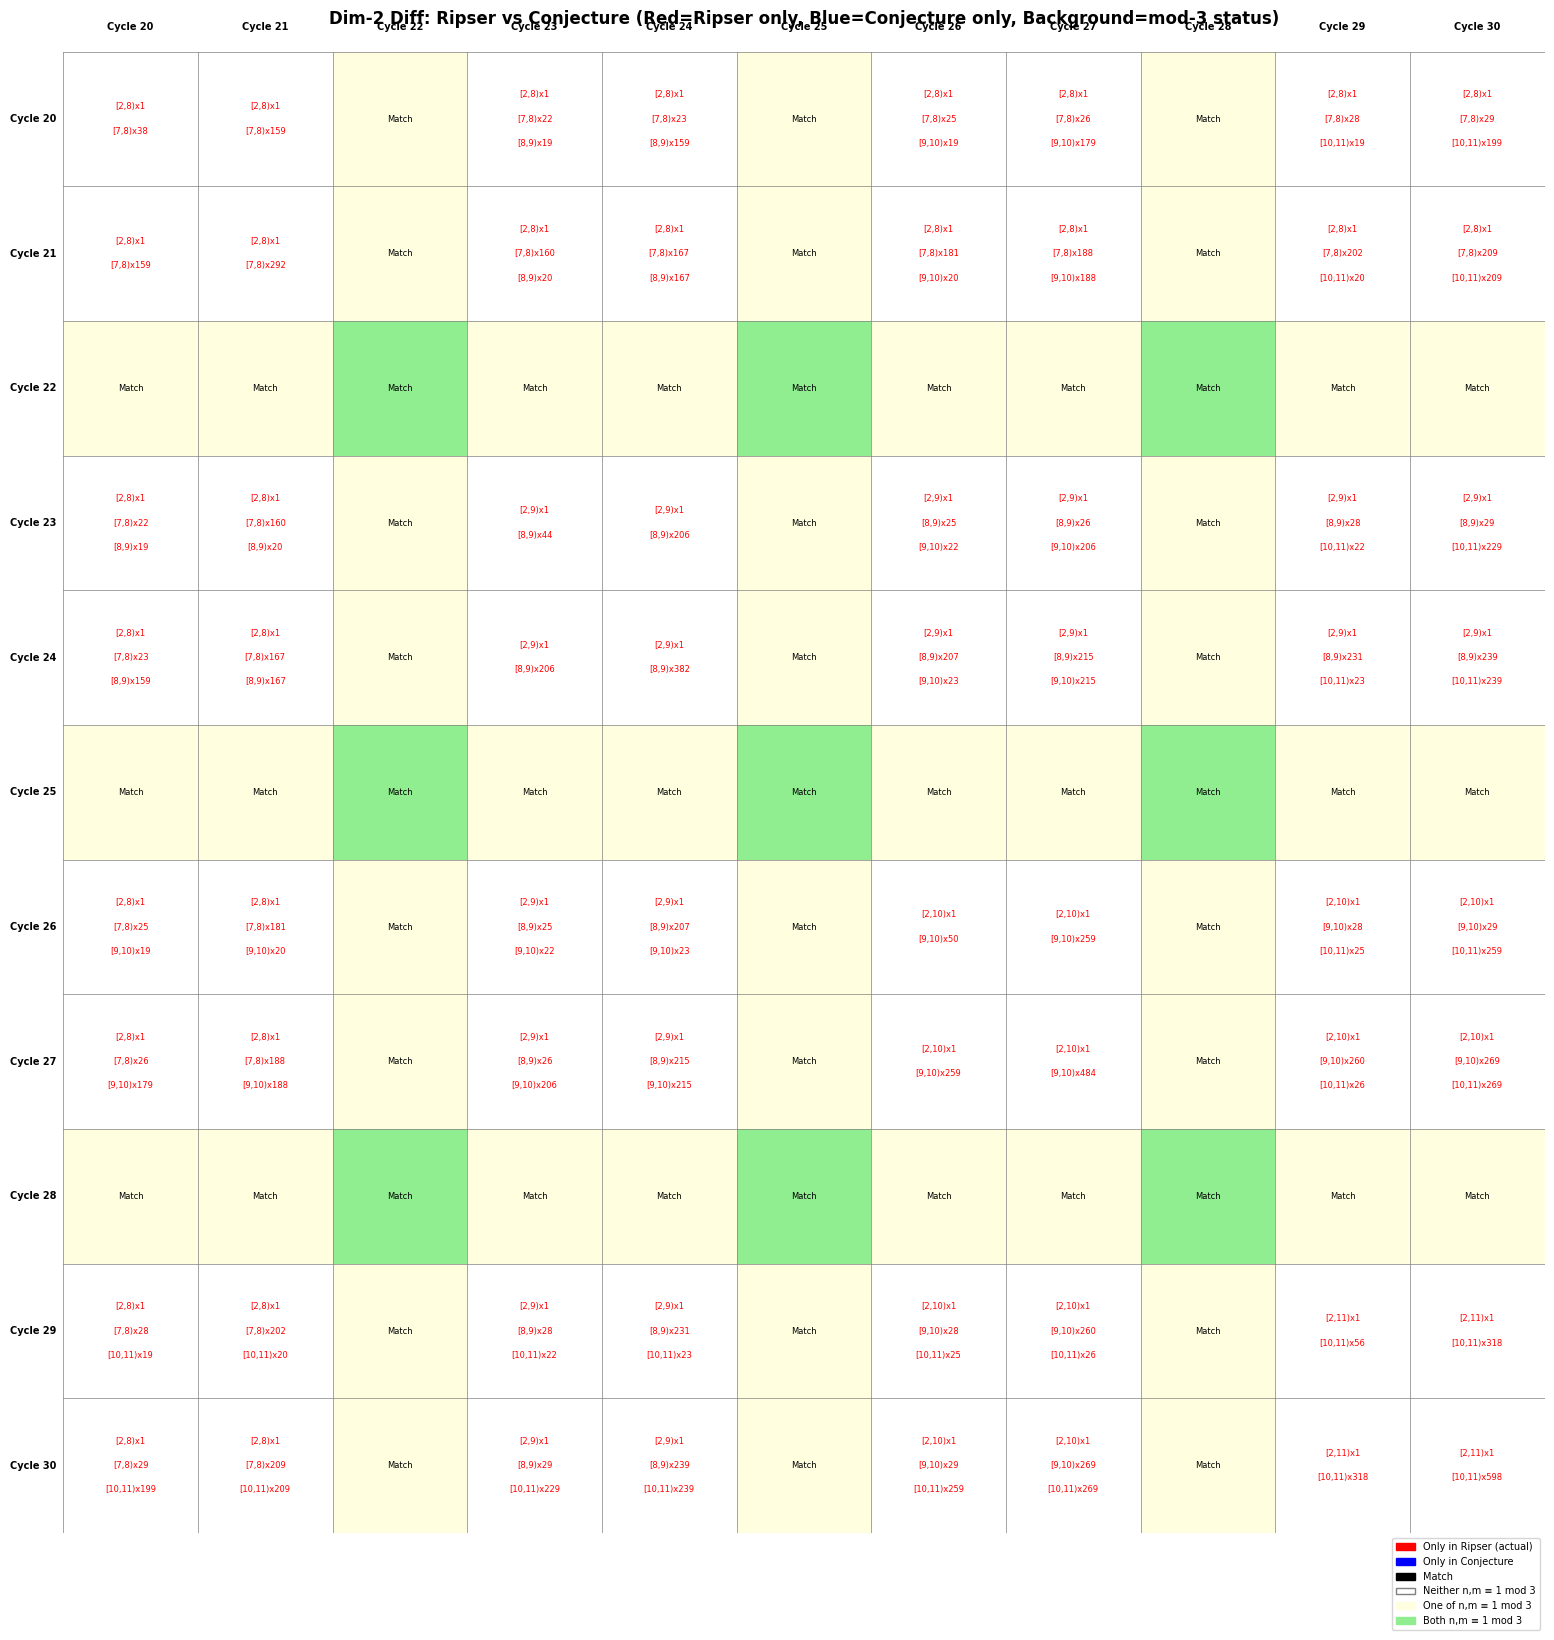

In [46]:
# AI Code for DIFF table --------------------------------------------->
import matplotlib.patches as mpatches

# 1. Labels already defined above

# 2. Build diff grid
diff_grid = []
for row_idx in range(grid_size):
    diff_row = []
    for col_idx in range(grid_size):
        ripser_cell = MGrid[row_idx][col_idx]
        conj_cell   = MGrid_conjecture_dict[row_idx][col_idx]

        # Extract dim-2 bars from Ripser
        ripser_bars = {}
        if ripser_cell and ripser_cell != 0:
            ripser_bars = ripser_cell.get(2, {})

        # Extract dim-2 bars from conjecture
        conj_bars = {}
        if conj_cell and conj_cell != 0:
            conj_bars = conj_cell.get(2, {})

        # Find bars unique to each side
        all_keys = set(ripser_bars.keys()) | set(conj_bars.keys())
        only_ripser = {}  # red
        only_conj   = {}  # blue

        for k in all_keys:
            r_mult = ripser_bars.get(k, 0)
            c_mult = conj_bars.get(k, 0)
            if r_mult != c_mult:
                # Show the differing multiplicity on each side if nonzero
                if r_mult > 0:
                    only_ripser[k] = r_mult
                if c_mult > 0:
                    only_conj[k] = c_mult

        diff_row.append((only_ripser, only_conj))
    diff_grid.append(diff_row)

# 3. Render table manually with colored text
fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_aspect('equal')
ax.axis('off')

col_w = 1.0  # width of each cell
row_h = 1.0  # height of each cell

# Fill cell backgrounds based on mod-3 condition
for row_idx in range(grid_size):
    n = row_idx + cyclemin
    for col_idx in range(grid_size):
        m = col_idx + cyclemin

        n_is_1mod3 = (n % 3 == 1)
        m_is_1mod3 = (m % 3 == 1)

        if n_is_1mod3 and m_is_1mod3:
            bg_color = 'lightgreen'
        elif n_is_1mod3 or m_is_1mod3:
            bg_color = 'lightyellow'
        else:
            bg_color = 'white'

        rect = mpatches.Rectangle(
            (col_idx * col_w, (grid_size - row_idx - 1) * row_h),
            col_w, row_h,
            facecolor=bg_color, edgecolor='none', zorder=0
        )
        ax.add_patch(rect)

# Draw grid lines
for i in range(grid_size + 1):
    ax.axhline(i, color='gray', linewidth=0.5, zorder=1)
    ax.axvline(i, color='gray', linewidth=0.5, zorder=1)

# Column headers (top)
for col_idx, label in enumerate(labels):
    ax.text((col_idx + 0.5) * col_w, grid_size + 0.15, label,
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# Row headers (left)
for row_idx, label in enumerate(labels):
    ax.text(-0.05, (grid_size - row_idx - 0.5) * row_h, label,
            ha='right', va='center', fontsize=7, fontweight='bold')

# Fill cells with text
for row_idx in range(grid_size):
    for col_idx in range(grid_size):
        only_ripser, only_conj = diff_grid[row_idx][col_idx]

        lines   = []  # list of (text, color)

        for (b, d), mult in sorted(only_ripser.items()):
            lines.append((f"[{b},{d})x{mult}", 'red'))
        for (b, d), mult in sorted(only_conj.items()):
            lines.append((f"[{b},{d})x{mult}", 'blue'))

        if not lines:
            lines = [("Match", 'black')]

        # Center the block of lines vertically in the cell
        n_lines = len(lines)
        cell_cx = (col_idx + 0.5) * col_w
        cell_cy = (grid_size - row_idx - 0.5) * row_h
        line_spacing = 0.18
        start_y = cell_cy + (n_lines - 1) * line_spacing / 2

        for li, (txt, color) in enumerate(lines):
            ax.text(cell_cx, start_y - li * line_spacing, txt,
                    ha='center', va='center', fontsize=6, color=color, zorder=2)

# Legend
red_patch    = mpatches.Patch(color='red',        label='Only in Ripser (actual)')
blue_patch   = mpatches.Patch(color='blue',       label='Only in Conjecture')
match_patch  = mpatches.Patch(color='black',      label='Match')
white_patch  = mpatches.Patch(facecolor='white', edgecolor='gray',  label='Neither n,m ≡ 1 mod 3')
yellow_patch = mpatches.Patch(color='lightyellow', label='One of n,m ≡ 1 mod 3')
green_patch  = mpatches.Patch(color='lightgreen',  label='Both n,m ≡ 1 mod 3')
ax.legend(handles=[red_patch, blue_patch, match_patch, white_patch, yellow_patch, green_patch],
          loc='upper right', bbox_to_anchor=(1.0, 0.0), fontsize=7)

plt.title("Dim-2 Diff: Ripser vs Conjecture (Red=Ripser only, Blue=Conjecture only, Background=mod-3 status)",
          weight='bold', pad=20)
plt.tight_layout()
plt.show()